In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures
import random

%matplotlib inline

In [2]:
words = open("names.txt", "r").read().splitlines()
len(words)

32033

In [3]:
# shuffle up the words
random.seed(42)
random.shuffle(words)

In [4]:
# get distinct chars across all words -- build vocab
chars = sorted(list(set("".join(words))))

# map chars to and from integers
# 0th char will be "." which denotes start/end of a word
char_to_int = {ch: idx + 1 for idx, ch in enumerate(chars)}
char_to_int["."] = 0
int_to_char = {idx: ch for ch, idx in char_to_int.items()}

print(char_to_int)
print(int_to_char)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build train, eval and test datasets
# X: 3 chars --> Y: next char
# For word "emma"
# ... --> e
# ..e --> m
# .em --> m
# emm --> a
# mma --> .

block_size = 8  # number of chars we take to predict the next one


def get_dataset(words):
    X = []
    y = []
    for w in words:
        block = [0] * block_size  # we start a block with all "."
        # iterate over every character in the word plus "." to mark the end
        # plus "." is necessary or else the loop will completely skip last char of the word
        for ch in w + ".":
            ix = char_to_int[ch]
            y.append(ix)
            X.append(block)
            block = block[1:] + [ix]  # move the window forward
    X = torch.tensor(X)
    y = torch.tensor(y)
    return X, y


# ------------------------------
# Viz get_dataset output first
# ------------------------------
# X, y = get_dataset(words[:25])
# for xout, yout in zip(X, y):
#     xout_str = "".join([int_to_char[ch.item()] for ch in xout])
#     yout_str = int_to_char[yout.item()]
#     print("{} --> {}".format(xout_str, yout_str))

# ------------------------------
# train/val/test datasets
# ------------------------------
n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)

Xtr, Ytr = get_dataset(words[:n1])
Xval, Yval = get_dataset(words[n1:n2])
Xtest, Ytest = get_dataset(words[n2:])

print("Training set: X={}, y={}".format(Xtr.shape, Ytr.shape))
print("Validation set: X={}, y={}".format(Xval.shape, Yval.shape))
print("Test set: X={}, y={}".format(Xtest.shape, Ytest.shape))


Training set: X=torch.Size([182625, 8]), y=torch.Size([182625])
Validation set: X=torch.Size([22655, 8]), y=torch.Size([22655])
Test set: X=torch.Size([22866, 8]), y=torch.Size([22866])


#### Full architecture + training code v1 (no Wavenet)

In [6]:
# ------------------------------------------------------------
# Rough outline of what we need
# i/p --> embedding + flattening --> linear 1 --> BN --> tanh --> linear 2 --> cross-entropy loss
# ------------------------------------------------------------

# g = torch.Generator().manual_seed(6)

# #
# vocab_size = len(chars) + 1
# block_size = 10  # already defined above; stating here for easy reference
# n_emb = 10
# n_hidden = 100

# # embedding layer; flattening would happen in training loop
# C = torch.randn((vocab_size, n_emb), generator=g)
# print(C.shape)

# # linear layer 1
# W1 = torch.randn((block_size * n_emb, n_hidden), generator=g)
# b1 = torch.zeros(n_hidden)

# # batchnorm parameter initialization
# # we want to start with gain = 1 and bias = 0. These params will be learned while training
# # in PyTorch nomenclature, bngain (gamma) and bnbias (beta) are referred to as "buffers"
# bngain = torch.ones((1, n_hidden))
# bnbias = torch.zeros((1, n_hidden))
# # running mean and std for running predictions post-training [no grad required]
# bnmean_running = torch.zeros((1, n_hidden))
# bnstd_running = torch.ones((1, n_hidden))

# # linear layer 2
# W2 = torch.randn((n_hidden, vocab_size), generator=g)
# b2 = torch.zeros(vocab_size, generator=g)

# parameters = [C, W1, W2, b2, bngain, bnbias]
# for p in parameters:
#     p.requires_grad = True


In [12]:
# Build the required layers similar to PyTorch API

g = torch.Generator().manual_seed(6)


class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g)
        self.weight /= fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, X):
        self.out = X @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class Tanh:
    def __call__(self, X):
        self.out = torch.tanh(X)
        return self.out

    def parameters(self):
        return []


# bn = gamma * (x - xmean())/(xstd() + eps) + beta --> when training
# bn = gamma * (x - x_running_mean)/x_running_std + beta --> when not training
class BatchNorm1d:
    def __init__(self, num_features, eps=1e-05, momentum=0.01):
        # batchnorm params
        self.num_features = num_features
        self.eps = eps
        self.gamma = torch.ones(num_features)  # batchnorm gain
        self.beta = torch.zeros(num_features)  # batchnorm bias
        # indicating batchnorm mode
        self.training = True
        # parameters for maintaining running mean and var
        self.x_running_mean = torch.zeros(num_features)
        self.x_running_var = torch.ones(num_features)
        self.momentum = momentum

    def __call__(self, X):
        # dim=0 because we calculate mean for each neuron across all examples
        if self.training:
            xmean = X.mean(0, keepdim=False)
            xvar = X.var(0, keepdim=False)
        else:
            xmean = self.x_running_mean
            xvar = self.x_running_var

        # perform batchnorm
        self.out = self.gamma * (X - xmean) / torch.sqrt(xvar + self.eps) + self.beta

        # maintain running mean and var
        if self.training:
            with torch.no_grad():
                self.x_running_mean = (1 - self.momentum) * self.x_running_mean + self.momentum * xmean
                self.x_running_var = (1 - self.momentum) * self.x_running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


# ------------------------------------------------------------
# # dummy example to ensure layers are working
# a = Linear(block_size * n_emb, n_hidden, n_hidden)
# a_in = torch.randn(10, block_size * n_emb)
# a_out = a(a_in)
# b = BatchNorm1d(a_out.shape[1])
# b(a_out)

# print(a.weight.shape, a_in.shape, a_out.shape)
# print(a.parameters())
# print(a_out.shape, b.out.shape)
# print(b.parameters())
# ------------------------------------------------------------

In [13]:
# Setup and initialize the architecture

vocab_size = len(chars) + 1
block_size = 8  # already defined above; stating here for easy reference
n_emb = 10
n_hidden = 100

# layers
C = torch.randn((vocab_size, n_emb))
layers = [
    Linear(fan_in=n_emb * block_size, fan_out=n_hidden, bias=False),  # bias false since we using BN next
    BatchNorm1d(num_features=n_hidden),
    Tanh(),
    Linear(fan_in=n_hidden, fan_out=n_hidden, bias=False),
    BatchNorm1d(num_features=n_hidden),
    Tanh(),
    Linear(fan_in=n_hidden, fan_out=vocab_size, bias=False),
    BatchNorm1d(num_features=vocab_size),
]


# additional initialization
with torch.no_grad():
    # (1) make last layer less confident
    layers[-1].gamma *= 0.1  # when not using batchnorm as last layer, use layers[-1].weight *= 0.1

    # (2) kaiming initialization for linear layers using tanh activation; only last layer doesnt use tanh
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3


# consolidate all parameters
parameters = [C] + [p for layer in layers for p in layer.parameters()]


# set requires_grad true for all parameters
for p in parameters:
    p.requires_grad = True


# total parameters in network
network_nparams = 0
for layer in layers:
    layer_nparams = sum([p.nelement() for p in layer.parameters()])
    network_nparams += layer_nparams
    print("{} --> total params: {}".format(layer.__class__.__name__, layer_nparams))
print("Total network params: {}".format(network_nparams))

Linear --> total params: 8000
BatchNorm1d --> total params: 200
Tanh --> total params: 0
Linear --> total params: 10000
BatchNorm1d --> total params: 200
Tanh --> total params: 0
Linear --> total params: 2700
BatchNorm1d --> total params: 54
Total network params: 21154


In [14]:
# full training loop

num_iterations = 200000
batch_size = 30
train_lossi = []

for i in range(num_iterations):
    # ----------------------------------BATCHING---------------------------------------------------------
    batch_idx = torch.randint(low=0, high=Xtr.shape[0], size=(batch_size,), generator=g)
    Xb, Yb = Xtr[batch_idx], Ytr[batch_idx]

    # ----------------------------------FORWARD PASS-----------------------------------------------------
    # fwd pass thro embedding + flattening layers
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)

    # fwd pass thro remaining layers
    for layer in layers:
        x = layer(x)

    # loss
    loss = F.cross_entropy(x, Yb)

    # ----------------------------------BACKWARD PASS----------------------------------------------------
    # run backward pass after nulling the existing gradients
    for p in parameters:
        p.grad = None
    loss.backward()

    # backpropgate gradients
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # ----------------------------------LOGGING----------------------------------------------------------
    # # we track log10 of cross-entropy loss for easier viz
    train_lossi.append(loss.log10().item())

    if i % 1000 == 0:
        print("Iter: {} | Train Loss: {}".format(i, loss.item()))
    # break


Iter: 0 | Train Loss: 3.315593719482422
Iter: 1000 | Train Loss: 2.586616277694702
Iter: 2000 | Train Loss: 2.238332509994507
Iter: 3000 | Train Loss: 2.423339366912842
Iter: 4000 | Train Loss: 3.0712194442749023
Iter: 5000 | Train Loss: 2.29030442237854
Iter: 6000 | Train Loss: 2.173941135406494
Iter: 7000 | Train Loss: 2.1607251167297363
Iter: 8000 | Train Loss: 2.2044572830200195
Iter: 9000 | Train Loss: 2.097029685974121
Iter: 10000 | Train Loss: 2.6898016929626465
Iter: 11000 | Train Loss: 2.332737684249878
Iter: 12000 | Train Loss: 2.1179168224334717
Iter: 13000 | Train Loss: 2.3199620246887207
Iter: 14000 | Train Loss: 2.3458619117736816
Iter: 15000 | Train Loss: 2.3412680625915527
Iter: 16000 | Train Loss: 2.4700474739074707
Iter: 17000 | Train Loss: 2.10959792137146
Iter: 18000 | Train Loss: 1.8299137353897095
Iter: 19000 | Train Loss: 2.0126616954803467
Iter: 20000 | Train Loss: 2.2602453231811523
Iter: 21000 | Train Loss: 2.06356143951416
Iter: 22000 | Train Loss: 1.99179685

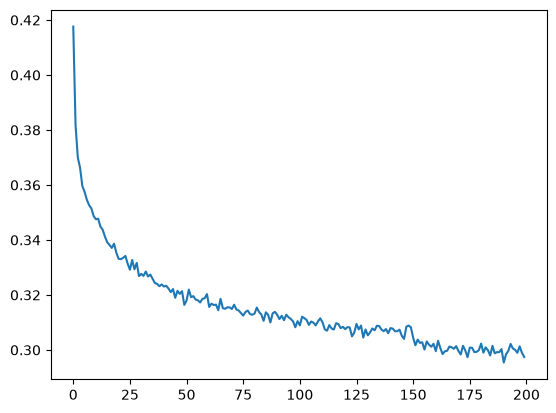

In [16]:
# Loss viz
def loss_visualization(train_loss):
    # visualize mean loss over "x" no. of iterations to obtain a less noisy graph
    plt.plot(torch.tensor(train_loss).view(-1, 1000).mean(dim=1))
    plt.show()


loss_visualization(train_lossi)

In [ ]:
# loss on train and val sets

for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False


def get_loss(data, labels, stage):
    emb = C[data]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, labels)
    print("Stage: {} | Loss: {}".format(stage, loss))
    return loss


training_loss = get_loss(data=Xtr, labels=Ytr, stage="training")
validation_loss = get_loss(data=Xval, labels=Yval, stage="validation")


Stage: training | Loss: 1.9338818788528442
Stage: validation | Loss: 2.0267598628997803


In [51]:
# use model to make predictions

total_names_to_generate = 20

for model_run in range(total_names_to_generate):
    out = []
    block = [0] * block_size

    while True:
        # passing one example through the network
        emb = C[block]
        x = emb.view(1, -1)
        for layer in layers:
            x = layer(x)
        # instead of loss we obtain the logits (probabilities) using softmax
        logits = F.softmax(x, dim=1)
        # make prediction based on the probab distribution
        next_char = torch.multinomial(logits, num_samples=1, generator=g).item()
        # update context and store the predictions
        block = block[1:] + [next_char]
        out.append(next_char)
        # if we predict next char as ".", we mark that as end of word
        if next_char == 0:
            break

    print("".join([int_to_char[c] for c in out]))

aidan.
lonce.
taniya.
shahin.
nices.
torrard.
danyla.
bishas.
suaky.
kameah.
giou.
emia.
abigan.
rayden.
hannaj.
ikoto.
grash.
natbella.
loreny.
ayjah.


In [45]:
block

[0, 12]

In [37]:
x

tensor([[-6.5881,  5.7923,  4.6054,  4.6652,  4.8049,  4.6345,  3.4572,  3.8338,
          3.9771,  3.7758,  5.2208,  5.3799,  4.6570,  5.2748,  4.3254,  3.1430,
          3.4891,  1.7957,  4.7612,  5.0229,  4.5256,  1.8005,  3.1894,  3.0536,
          2.3295,  3.6872,  4.2719]], grad_fn=<AddBackward0>)